# Modelo Original







# 1. Introducción

## 2. Análisis exploratorio de datos


In [1]:
import tensorflow as tf


In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imetomi/eur-usd-forex-pair-historical-data-2002-2019")

print("Path to dataset files:", path)

C:\Users\planeacion\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\planeacion\.cache\kagglehub\datasets\imetomi\eur-usd-forex-pair-historical-data-2002-2019\versions\2


In [3]:

for file in os.listdir(path):
    print(file)

eurusd_hour.csv
eurusd_minute.csv
eurusd_news.csv


In [4]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "eurusd_minute.csv"))
print(df.head(10))
print(df.shape)

         Date   Time      BO      BH      BL      BC     BCh      AO      AH  \
0  2005-01-02  18:29  1.3555  1.3555  1.3555  1.3555  0.0000  1.3565  1.3565   
1  2005-01-02  18:38  1.3555  1.3555  1.3555  1.3555  0.0000  1.3565  1.3565   
2  2005-01-02  18:51  1.3562  1.3562  1.3562  1.3562  0.0000  1.3572  1.3572   
3  2005-01-02  18:52  1.3560  1.3560  1.3560  1.3560  0.0000  1.3570  1.3570   
4  2005-01-02  18:55  1.3563  1.3563  1.3563  1.3563  0.0000  1.3573  1.3573   
5  2005-01-02  18:57  1.3562  1.3562  1.3562  1.3562  0.0000  1.3572  1.3572   
6  2005-01-02   19:4  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   
7  2005-01-02   19:7  1.3565  1.3565  1.3564  1.3564  0.0001  1.3575  1.3575   
8  2005-01-02  19:10  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   
9  2005-01-02  19:12  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   

       AL      AC     ACh  
0  1.3565  1.3565  0.0000  
1  1.3565  1.3565  0.0000  
2  1.3572  1.3572  0.0000  
3  1.35

In [5]:
print(df.columns.tolist())
print(df.dtypes)
print(df.head())
print('No. of rows, columns:', df.shape)

['Date', 'Time', 'BO', 'BH', 'BL', 'BC', 'BCh', 'AO', 'AH', 'AL', 'AC', 'ACh']
Date     object
Time     object
BO      float64
BH      float64
BL      float64
BC      float64
BCh     float64
AO      float64
AH      float64
AL      float64
AC      float64
ACh     float64
dtype: object
         Date   Time      BO      BH      BL      BC  BCh      AO      AH  \
0  2005-01-02  18:29  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
1  2005-01-02  18:38  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2  2005-01-02  18:51  1.3562  1.3562  1.3562  1.3562  0.0  1.3572  1.3572   
3  2005-01-02  18:52  1.3560  1.3560  1.3560  1.3560  0.0  1.3570  1.3570   
4  2005-01-02  18:55  1.3563  1.3563  1.3563  1.3563  0.0  1.3573  1.3573   

       AL      AC  ACh  
0  1.3565  1.3565  0.0  
1  1.3565  1.3565  0.0  
2  1.3572  1.3572  0.0  
3  1.3570  1.3570  0.0  
4  1.3573  1.3573  0.0  
No. of rows, columns: (5618819, 12)


In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
import matplotlib
import seaborn
print(matplotlib.__version__)
print(seaborn.__version__)

3.7.5
0.13.2


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


### 2.1. Descripción y definición de la variables 

In [9]:
sns.set_style("darkgrid")

| Variable | Descripción |
|:--------:|:------------|
| **Time** | Hora en que se midió el precio |
| **BO** | Precio de apertura Bid<sup>1</sup> |
| **BH** | Precio más alto en el período Bid |
| **BL** | Precio más bajo en el período Bid |
| **BC** | Precio de cierre Bid |
| **BCh** | Cambio entre apertura y cierre Bid |
| **AO** | Precio de apertura Ask<sup>2</sup> |
| **AH** | Precio más alto en el período Ask |
| **AL** | Precio más bajo en el período Ask |

<sup>1</sup> **Bid** — Precio al que el mercado compra (perspectiva del vendedor).  
<sup>2</sup> **Ask** — Precio al que el mercado vende (perspectiva del comprador).

&bullet; No hay presencia de valores faltantes en el dataset

In [10]:
df.isna().sum()


Date    0
Time    0
BO      0
BH      0
BL      0
BC      0
BCh     0
AO      0
AH      0
AL      0
AC      0
ACh     0
dtype: int64

In [11]:
# Combinar Date y Time para la el horario exacto
df_time = df.copy()

if 'Date' in df_time.columns and 'Time' in df_time.columns:
    df_time['Datetime'] = pd.to_datetime(df_time['Date'] + ' ' + df_time['Time'])
    df_time = df_time.set_index('Datetime')
    df_time = df_time.drop(columns=['Date', 'Time'])
    df_time = df_time.sort_index()

print(df_time.head())
print(df_time.shape)



                         BO      BH      BL      BC  BCh      AO      AH  \
Datetime                                                                   
2005-01-02 18:29:00  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2005-01-02 18:38:00  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2005-01-02 18:51:00  1.3562  1.3562  1.3562  1.3562  0.0  1.3572  1.3572   
2005-01-02 18:52:00  1.3560  1.3560  1.3560  1.3560  0.0  1.3570  1.3570   
2005-01-02 18:55:00  1.3563  1.3563  1.3563  1.3563  0.0  1.3573  1.3573   

                         AL      AC  ACh  
Datetime                                  
2005-01-02 18:29:00  1.3565  1.3565  0.0  
2005-01-02 18:38:00  1.3565  1.3565  0.0  
2005-01-02 18:51:00  1.3572  1.3572  0.0  
2005-01-02 18:52:00  1.3570  1.3570  0.0  
2005-01-02 18:55:00  1.3573  1.3573  0.0  
(5618819, 10)


In [12]:
df_5m = df_time.resample('5T').median().dropna()

print(df_5m.shape)
print(df_5m.head())
print(df_5m.tail() )

(1153890, 10)
                          BO       BH       BL       BC  BCh       AO  \
Datetime                                                                
2005-01-02 18:25:00  1.35550  1.35550  1.35550  1.35550  0.0  1.35650   
2005-01-02 18:35:00  1.35550  1.35550  1.35550  1.35550  0.0  1.35650   
2005-01-02 18:50:00  1.35610  1.35610  1.35610  1.35610  0.0  1.35710   
2005-01-02 18:55:00  1.35625  1.35625  1.35625  1.35625  0.0  1.35725   
2005-01-02 19:00:00  1.35640  1.35640  1.35640  1.35640  0.0  1.35740   

                          AH       AL       AC  ACh  
Datetime                                             
2005-01-02 18:25:00  1.35650  1.35650  1.35650  0.0  
2005-01-02 18:35:00  1.35650  1.35650  1.35650  0.0  
2005-01-02 18:50:00  1.35710  1.35710  1.35710  0.0  
2005-01-02 18:55:00  1.35725  1.35725  1.35725  0.0  
2005-01-02 19:00:00  1.35740  1.35740  1.35740  0.0  
                           BO       BH        BL       BC       BCh       AO  \
Datetime        

Para cada ventana de 5 minutos se aplicó la siguiente agregación:

| Columna | Función | Descripción |
|:-------:|:-------:|:------------|
| **BO**, **AO** | `first` | Primer precio del intervalo (apertura) |
| **BH**, **AH** | `max` | Precio más alto del intervalo |
| **BL**, **AL** | `min` | Precio más bajo del intervalo |
| **BC**, **AC** | `last` | Último precio del intervalo (cierre) |
| **BCh**, **ACh** | `sum` | Suma de cambios en el intervalo |

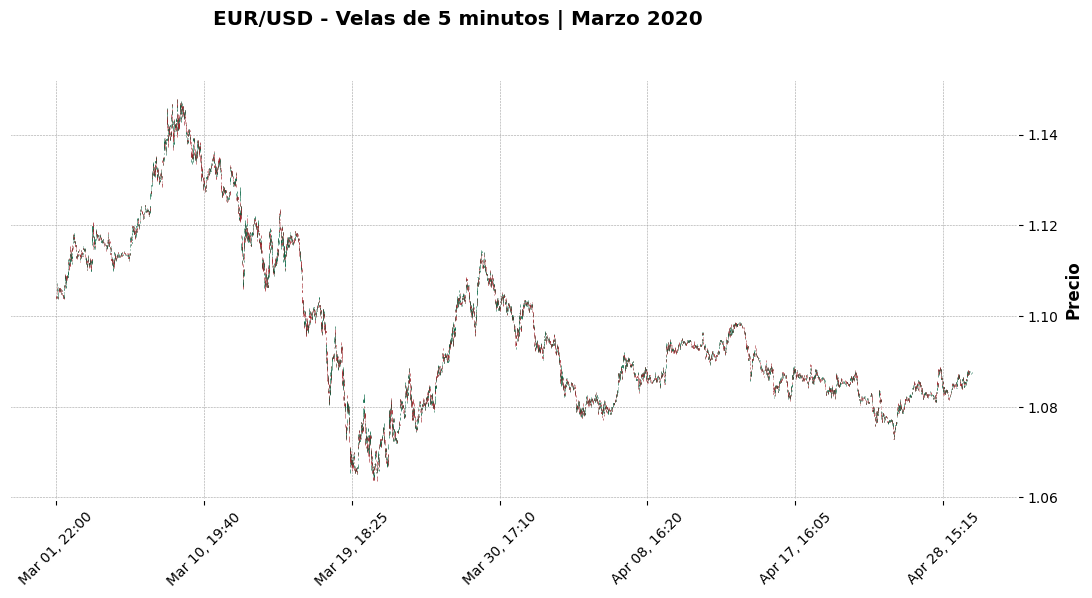

In [13]:
import mplfinance as mpf

df_plot = df_5m['2020-03-01':'2020-04-29'].copy()

df_plot = df_plot.rename(columns={
    'BO': 'Open',
    'BH': 'High',
    'BL': 'Low',
    'BC': 'Close'
})

mpf.plot(df_plot[['Open', 'High', 'Low', 'Close']],
         type='candle',
         style='charles',
         title='EUR/USD - Velas de 5 minutos | Marzo 2020',
         ylabel='Precio',
         figsize=(14, 6))

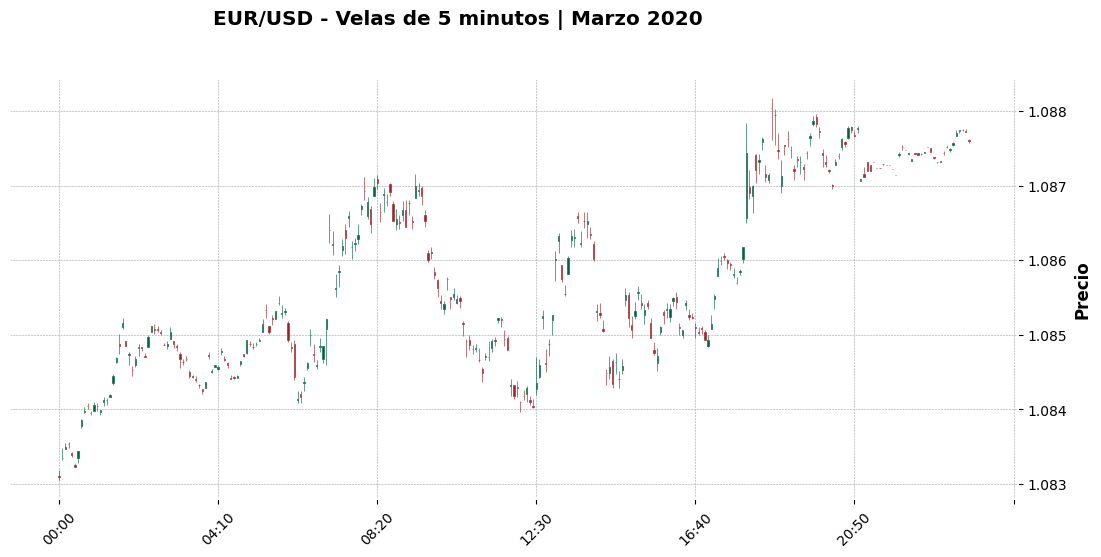

In [14]:
df_plot = df_5m.loc['2020-04-29'].copy()
df_plot = df_plot.rename(columns={
    'BO': 'Open',
    'BH': 'High',
    'BL': 'Low',
    'BC': 'Close'
})

mpf.plot(df_plot[['Open', 'High', 'Low', 'Close']],
         type='candle',
         style='charles',
         title='EUR/USD - Velas de 5 minutos | Marzo 2020',
         ylabel='Precio',
         figsize=(14, 6))

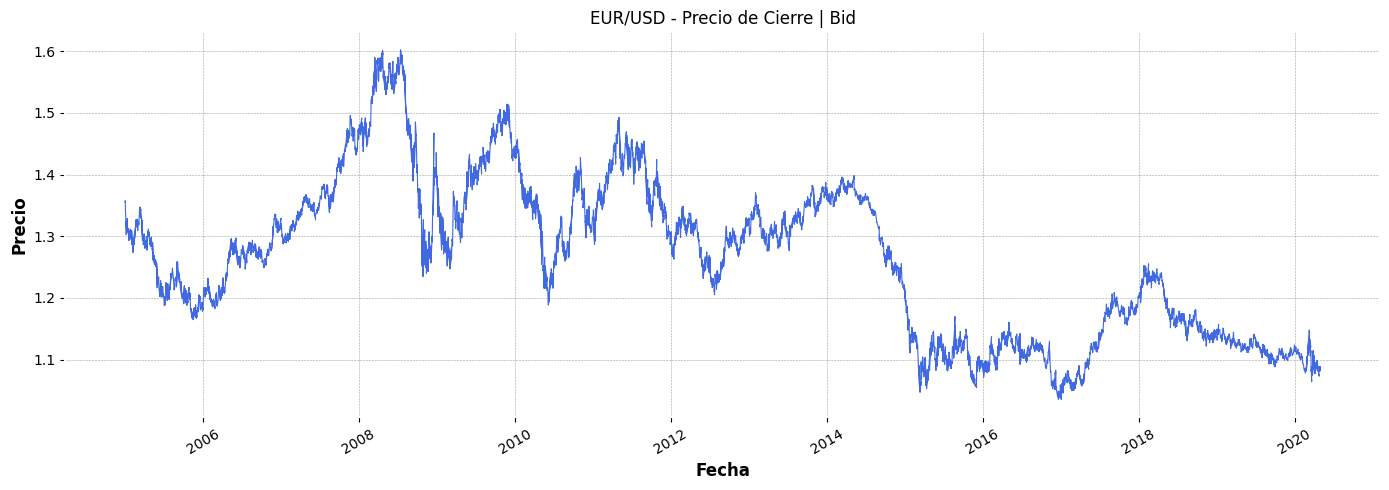

In [15]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_5m.index, df_5m['BC'], color='royalblue', linewidth=0.8)
plt.title('EUR/USD - Precio de Cierre | Bid')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

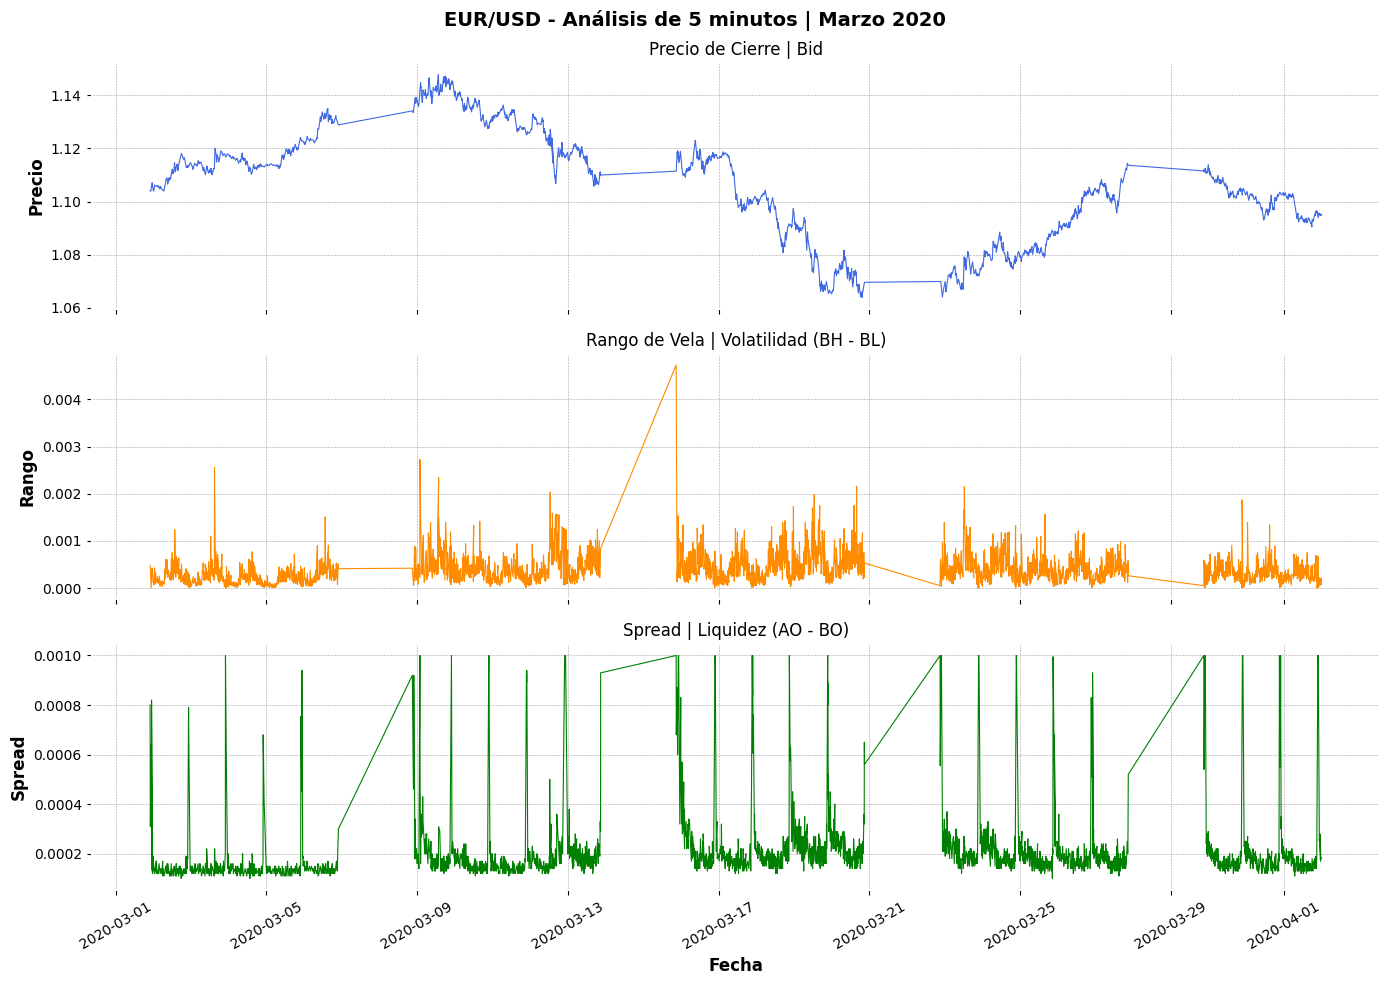

In [16]:
import matplotlib.pyplot as plt

df_plot = df_5m['2020-03-01':'2020-04-01'].copy()
df_plot['Rango'] = df_plot['BH'] - df_plot['BL']
df_plot['Spread'] = df_plot['AO'] - df_plot['BO']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Precio de cierre
axes[0].plot(df_plot.index, df_plot['BC'], color='royalblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Rango
axes[1].plot(df_plot.index, df_plot['Rango'], color='darkorange', linewidth=0.8)
axes[1].set_title('Rango de Vela | Volatilidad (BH - BL)')
axes[1].set_ylabel('Rango')

# Spread
axes[2].plot(df_plot.index, df_plot['Spread'], color='green', linewidth=0.8)
axes[2].set_title('Spread | Liquidez (AO - BO)')
axes[2].set_ylabel('Spread')
axes[2].set_xlabel('Fecha')

plt.suptitle('EUR/USD - Análisis de 5 minutos | Marzo 2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

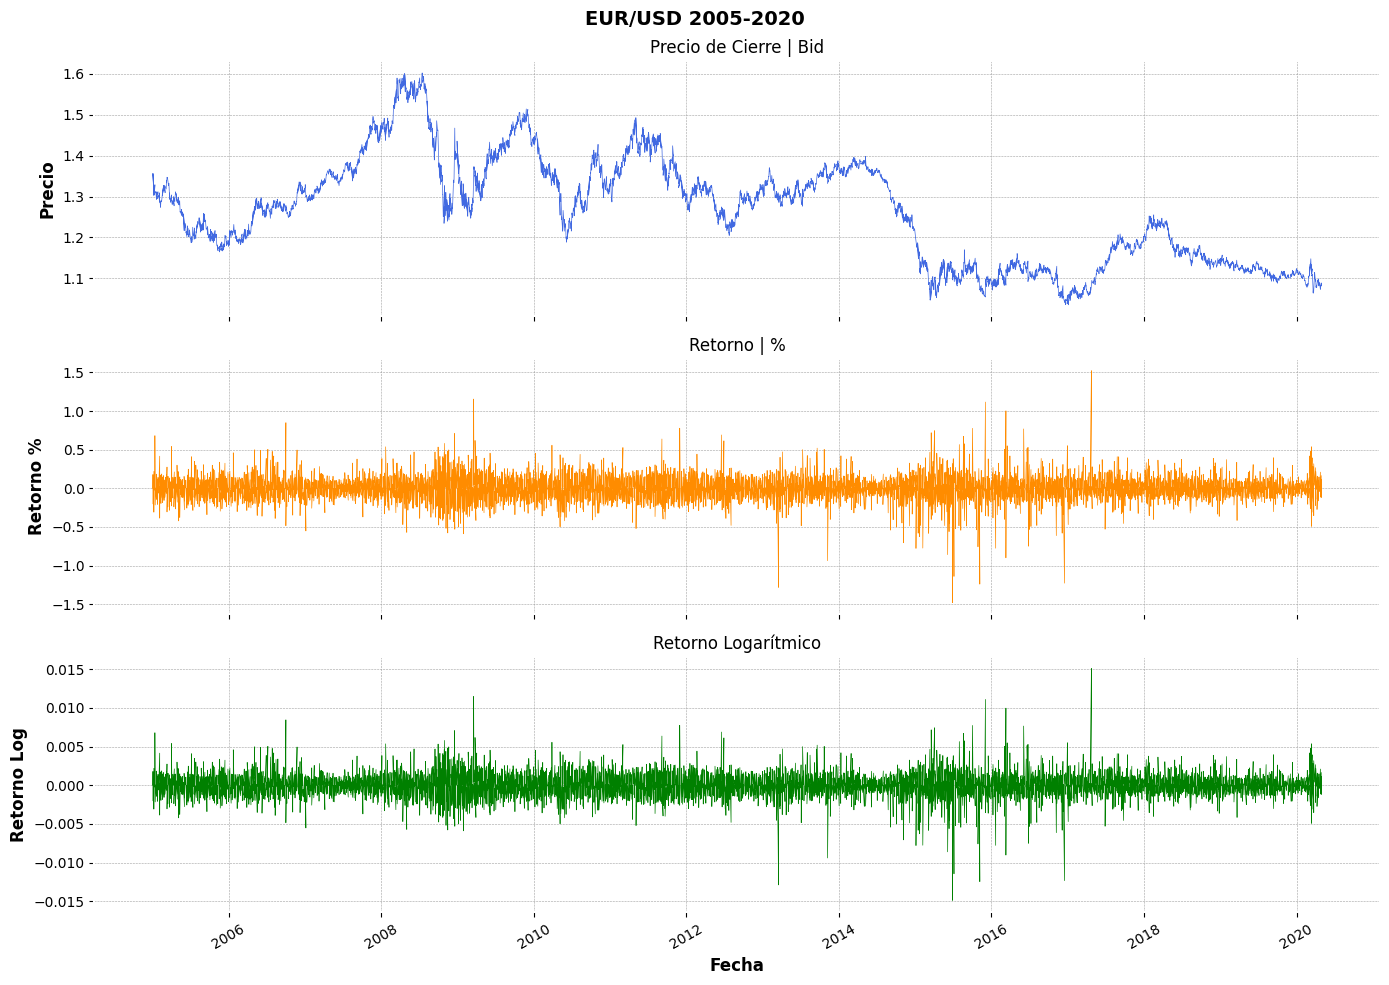

In [17]:
df_5m['Retorno'] = df_5m['BC'].pct_change() * 100
df_5m['Retorno_log'] = np.log(df_5m['BC'] / df_5m['BC'].shift(1))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Precio de cierre
axes[0].plot(df_5m.index, df_5m['BC'], color='royalblue', linewidth=0.5)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Retorno %
axes[1].plot(df_5m.index, df_5m['Retorno'], color='darkorange', linewidth=0.5)
axes[1].set_title('Retorno | %')
axes[1].set_ylabel('Retorno %')

# Retorno logarítmico
axes[2].plot(df_5m.index, df_5m['Retorno_log'], color='green', linewidth=0.5)
axes[2].set_title('Retorno Logarítmico')
axes[2].set_ylabel('Retorno Log')
axes[2].set_xlabel('Fecha')

plt.suptitle('EUR/USD 2005-2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

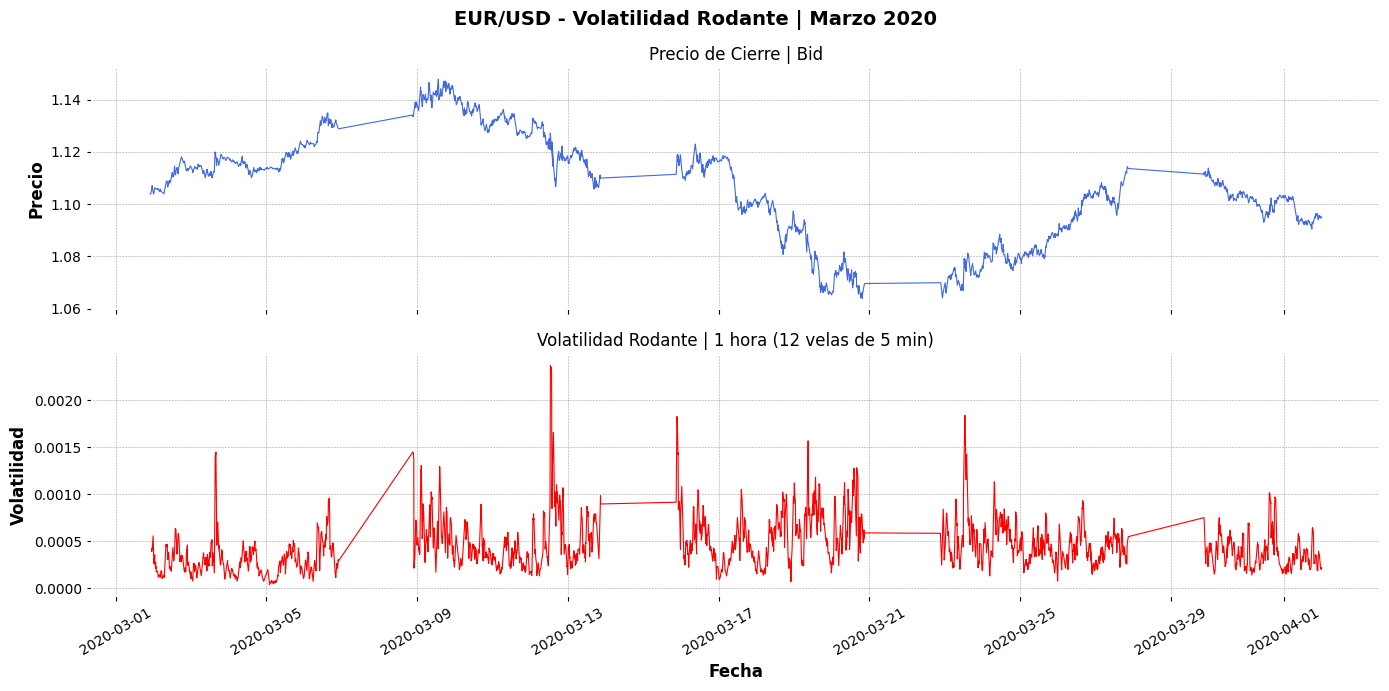

In [18]:
df_plot = df_5m['2020-03-01':'2020-04-01'].copy()
df_plot['Retorno_log'] = np.log(df_plot['BC'] / df_plot['BC'].shift(1))
df_plot['Volatilidad'] = df_plot['Retorno_log'].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Precio de cierre
axes[0].plot(df_plot.index, df_plot['BC'], color='royalblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Volatilidad
axes[1].plot(df_plot.index, df_plot['Volatilidad'], color='red', linewidth=0.8)
axes[1].set_title('Volatilidad Rodante | 1 hora (12 velas de 5 min)')
axes[1].set_ylabel('Volatilidad')
axes[1].set_xlabel('Fecha')

plt.suptitle('EUR/USD - Volatilidad Rodante | Marzo 2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#1.1. Tendencia 


In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [20]:
trend_model = LinearRegression(fit_intercept=True)
trend_model.fit(np.arange(df_5m.shape[0]).reshape((-1,1)), df_5m['BC'])

LinearRegression()

In [21]:
print('Trend model coefficient={} and intercept={}'.format(trend_model.coef_[0], trend_model.intercept_))

Trend model coefficient=-2.335020739718395e-07 and intercept=1.4022674106390598


In [22]:
residuals = np.array(df_5m['BC']) - trend_model.predict(np.arange(df_5m.shape[0]).reshape((-1,1)))
residuals

array([-0.04676741, -0.04676718, -0.04616694, ..., -0.0450824 ,
       -0.04511217, -0.04523194])

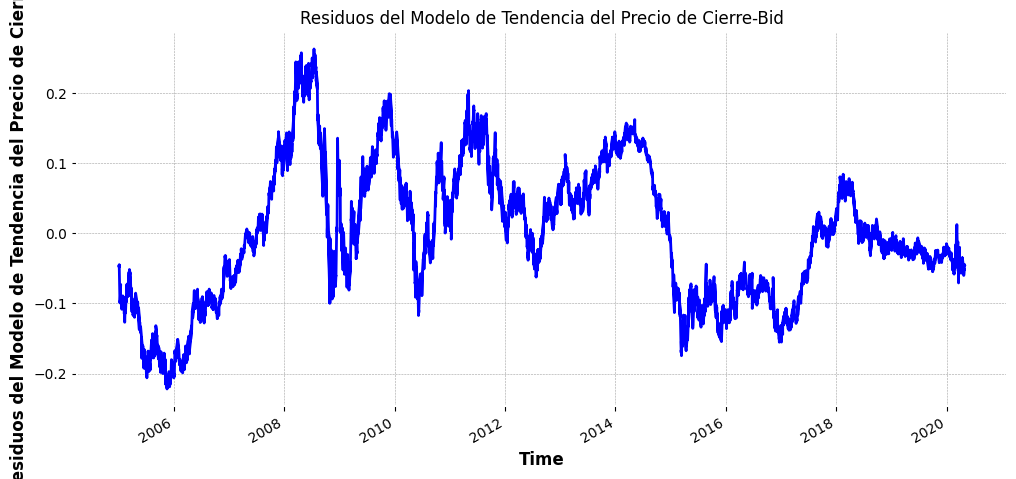

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5.5))
pd.Series(data=residuals, index=df_5m.index).plot(color='b')
plt.title('Residuos del Modelo de Tendencia del Precio de Cierre-Bid')
plt.xlabel('Time')
plt.ylabel('Residuos del Modelo de Tendencia del Precio de Cierre-Bid')
plt.xticks(rotation=30);

#1.2. Estacionalidad

#1.3. Gráfico de subserie estacional

         Year Quarter  Quarterly Mean  Quarterly Standard Deviation
2005-Q1  2005      Q1       -0.090163                      0.009550
2005-Q2  2005      Q2       -0.138756                      0.038245
2005-Q3  2005      Q3       -0.171438                      0.013954
2005-Q4  2005      Q4       -0.198709                      0.011792
2006-Q1  2006      Q1       -0.180489                      0.008270


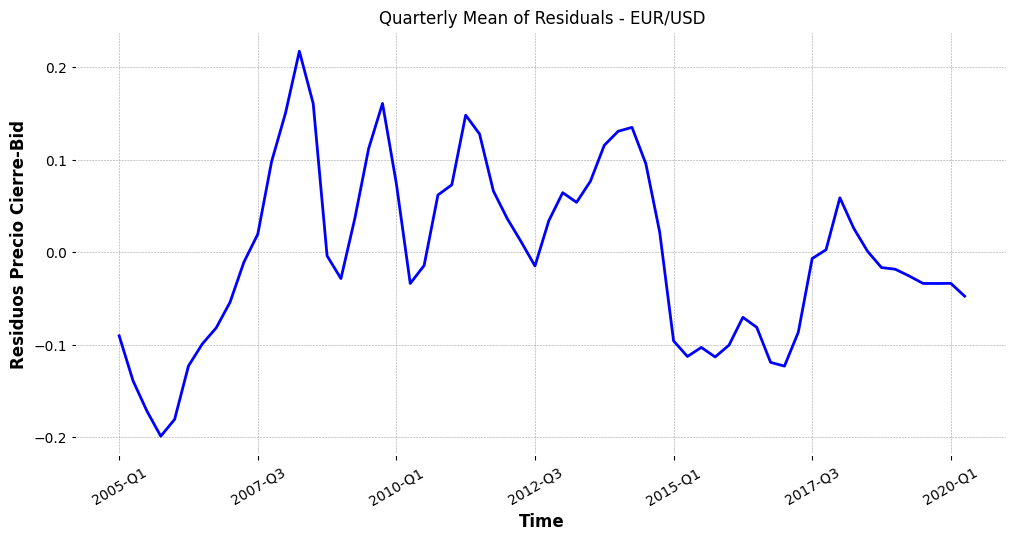

In [24]:
# 1. Resamplea residuos a mensual
residuals_series = pd.Series(data=residuals, index=df_5m.index)
residuals_monthly = residuals_series.resample('M').median()

# 2. Crea el DataFrame base
data = residuals_monthly.reset_index()
data.columns = ['Date', 'Residuals']
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

# 3. Mapea trimestres
month_quarter_map = {1: 'Q1', 2: 'Q1', 3: 'Q1',
                     4: 'Q2', 5: 'Q2', 6: 'Q2',
                     7: 'Q3', 8: 'Q3', 9: 'Q3',
                     10: 'Q4', 11: 'Q4', 12: 'Q4'}
data['Quarter'] = data['Month'].map(lambda m: month_quarter_map.get(m))

# 4. Calcula media y desviación estándar trimestral
seasonal_sub_series_data = data.groupby(by=['Year', 'Quarter'])['Residuals'].aggregate([np.mean, np.std])
seasonal_sub_series_data.columns = ['Quarterly Mean', 'Quarterly Standard Deviation']

# 5. Crea índice Year-Quarter
seasonal_sub_series_data.reset_index(inplace=True)
seasonal_sub_series_data.index = seasonal_sub_series_data['Year'].astype(str) + '-' + seasonal_sub_series_data['Quarter']

print(seasonal_sub_series_data.head())

# 6. Grafica
plt.figure(figsize=(12, 5.5))
seasonal_sub_series_data['Quarterly Mean'].plot(color='b')
plt.title('Quarterly Mean of Residuals - EUR/USD')
plt.xlabel('Time')
plt.ylabel('Residuos Precio Cierre-Bid')
plt.xticks(rotation=30)
plt.show()


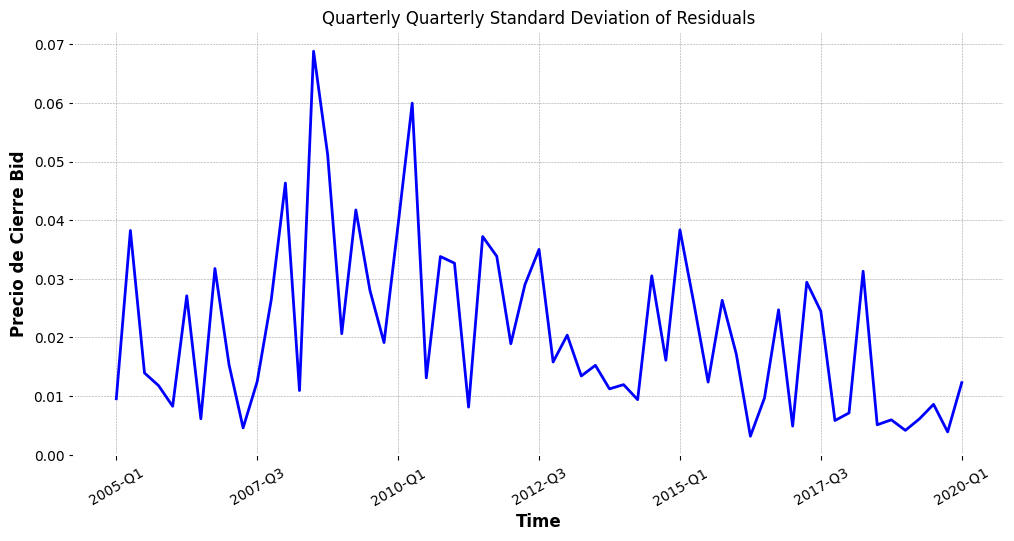

In [25]:
plt.figure(figsize=(12, 5.5))
seasonal_sub_series_data['Quarterly Standard Deviation'].plot(color='b')
plt.title('Quarterly Quarterly Standard Deviation of Residuals')
plt.xlabel('Time')
plt.ylabel('Precio de Cierre Bid')
plt.xticks(rotation=30);

Gráficos de cajas múltiples

Text(0, 0.5, 'Residuos Precio Cierre-Bid')

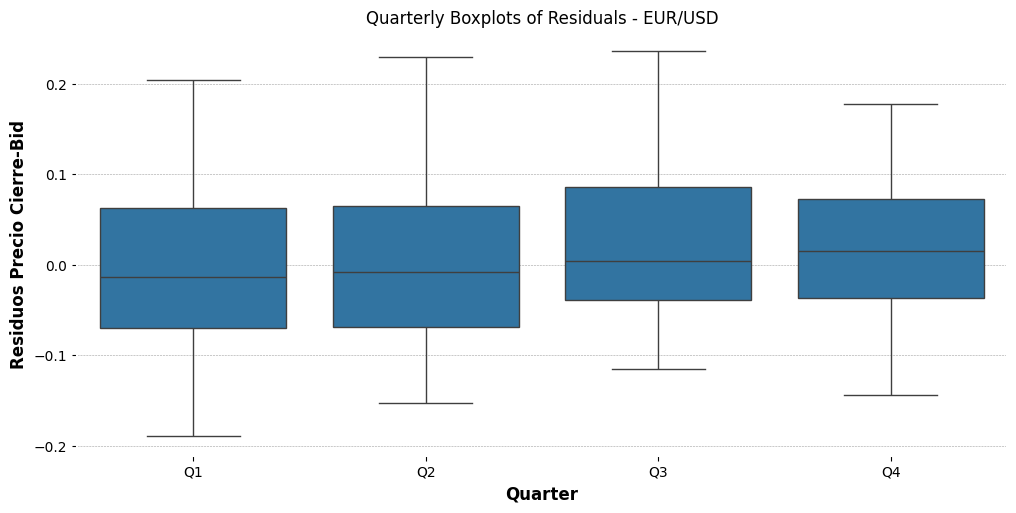

In [26]:
plt.figure(figsize=(12, 5.5))
g = sns.boxplot(data=data[data['Year'] > 2005], y='Residuals', x='Quarter')
g.set_title('Quarterly Boxplots of Residuals - EUR/USD')
g.set_xlabel('Quarter')
g.set_ylabel('Residuos Precio Cierre-Bid')

Comportamiento Cíclico

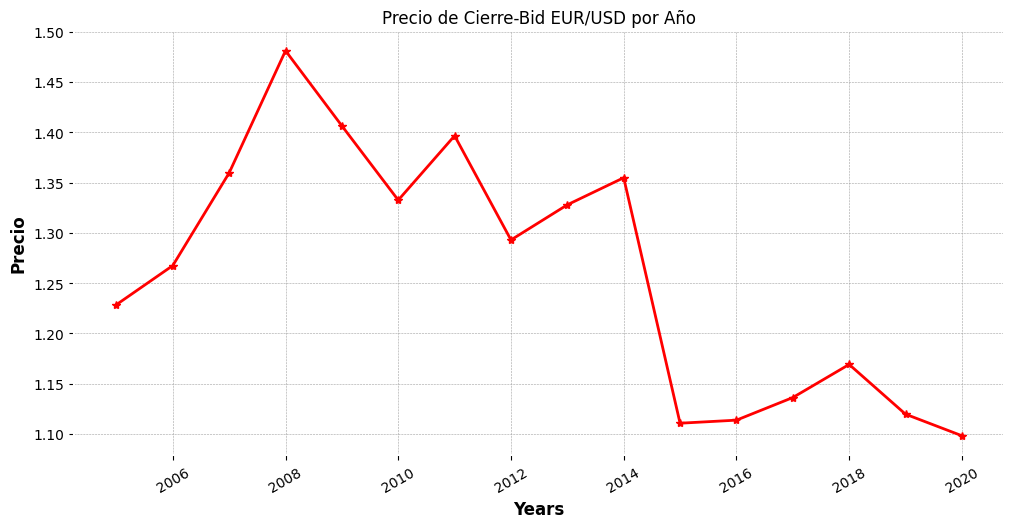

In [27]:
# Promedio anual del precio de cierre
annual = df_5m['BC'].resample('Y').median()

plt.figure(figsize=(12, 5.5))
plt.plot(annual.index.year, annual.values, linestyle='-', marker='*', color='r')
plt.title('Precio de Cierre-Bid EUR/USD por Año')
plt.ylabel('Precio')
plt.xlabel('Years')
plt.xticks(rotation=30)
plt.show()

#1.3. Modelos irregulares

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

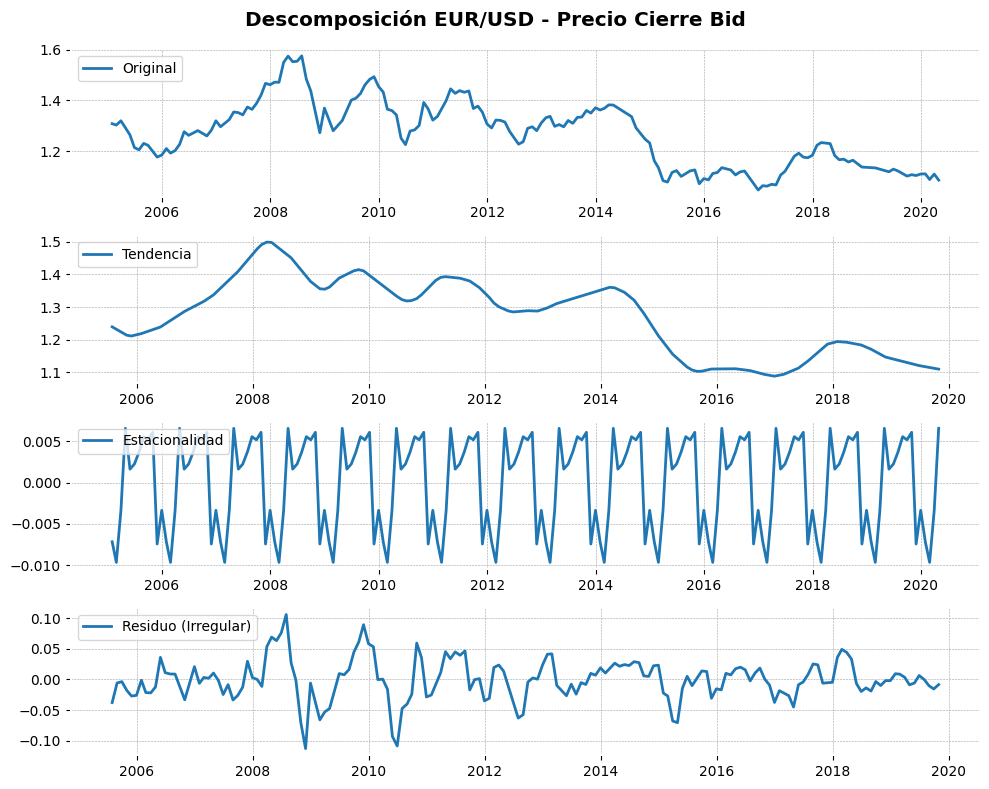

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Resamplea a mensual para que sea manejable
bc_monthly = df_5m['BC'].resample('M').median()

# Descomposición
decomposition = seasonal_decompose(bc_monthly, model='additive', period=12)

# Gráfica
plt.figure(figsize=(10, 8))
plt.subplot(411)
plt.plot(bc_monthly, label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuo (Irregular)')
plt.legend(loc='upper left')

plt.suptitle('Descomposición EUR/USD - Precio Cierre Bid')
plt.tight_layout()
plt.show()


Modelos de análisis de series temporales

Text(0, 0.5, 'Precio de cierre')

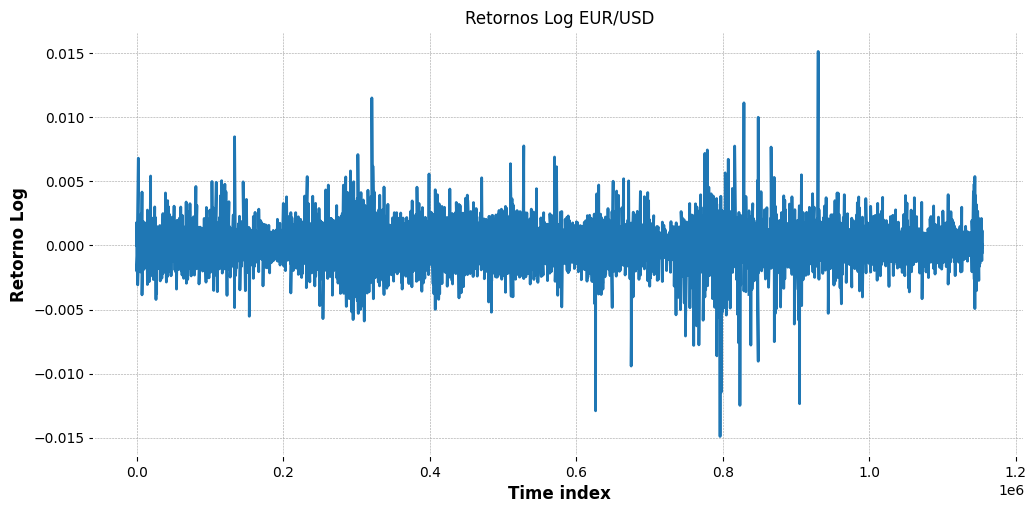

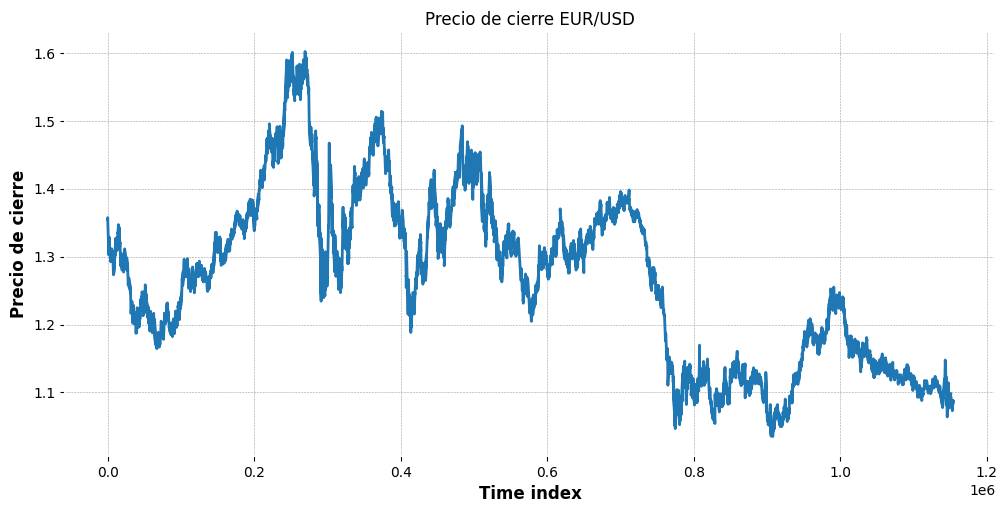

In [30]:
plt.figure(figsize=(12, 5.5))
g = sns.lineplot(data=df_5m['Retorno_log'].reset_index(drop=True))
g.set_title('Retornos Log EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Retorno Log')

plt.figure(figsize=(12, 5.5))
g = sns.lineplot(data=df_5m['BC'].reset_index(drop=True))
g.set_title('Precio de cierre EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Precio de cierre')




Camino Aleatorio

Text(0, 0.5, 'Suma acumulada Precio de cierre')

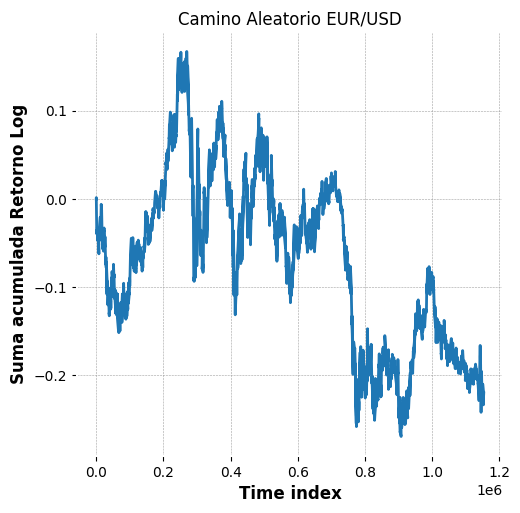

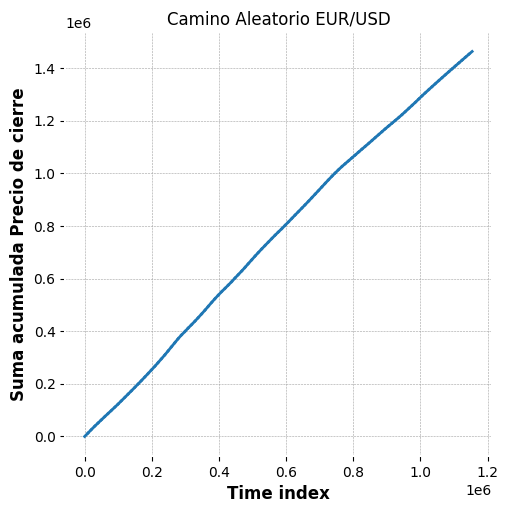

In [31]:
random_walk = np.cumsum(df_5m['Retorno_log'].dropna())

plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(data=random_walk.reset_index(drop=True))
g.set_title('Camino Aleatorio EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Suma acumulada Retorno Log')

random_walk = np.cumsum(df_5m['BC'].dropna())

plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(data=random_walk.reset_index(drop=True))
g.set_title('Camino Aleatorio EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Suma acumulada Precio de cierre')

Modelos de tendencia

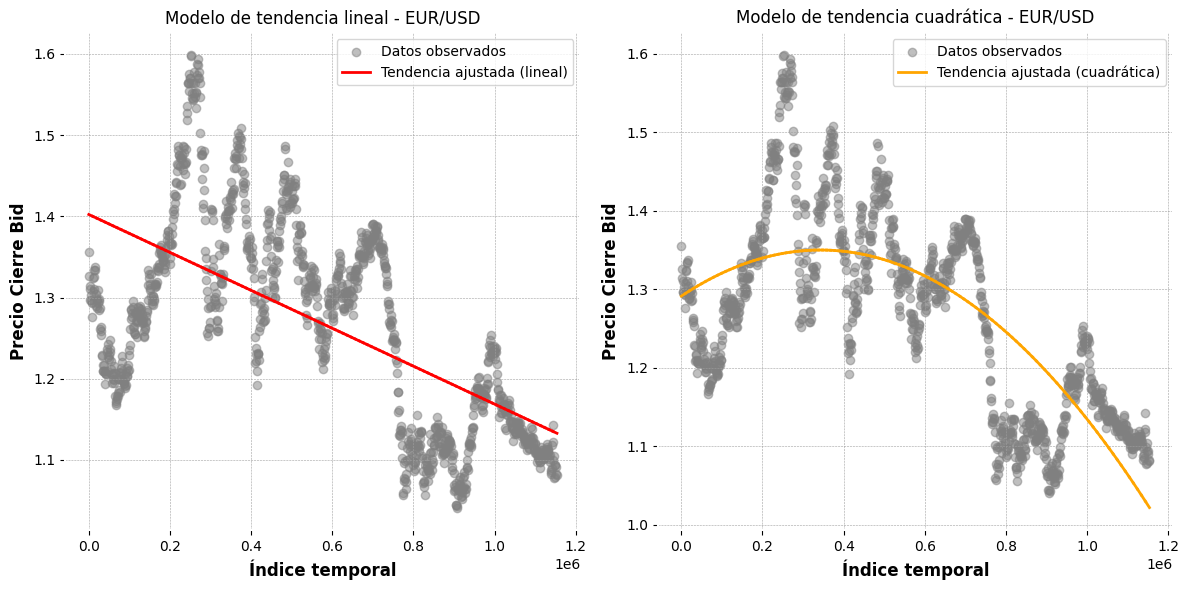

In [32]:
# Índice temporal
t = np.arange(df_5m.shape[0])

# Tendencia lineal ya calculada
fitted_trend_linear = trend_model.predict(t.reshape(-1, 1))

# Tendencia cuadrática con polyfit
coeffs_quadratic = np.polyfit(t, df_5m['BC'], 2)
fitted_trend_quadratic = np.polyval(coeffs_quadratic, t)

# Grafica
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(t[::1000], df_5m['BC'].values[::1000], color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, fitted_trend_linear, color='red', label='Tendencia ajustada (lineal)')
plt.title('Modelo de tendencia lineal - EUR/USD')
plt.xlabel('Índice temporal')
plt.ylabel('Precio Cierre Bid')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t[::1000], df_5m['BC'].values[::1000], color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, fitted_trend_quadratic, color='orange', label='Tendencia ajustada (cuadrática)')
plt.title('Modelo de tendencia cuadrática - EUR/USD')
plt.xlabel('Índice temporal')
plt.ylabel('Precio Cierre Bid')
plt.legend()

plt.tight_layout()
plt.show()

Autocorrelación y autocorrelación parcial

<Figure size 550x550 with 0 Axes>

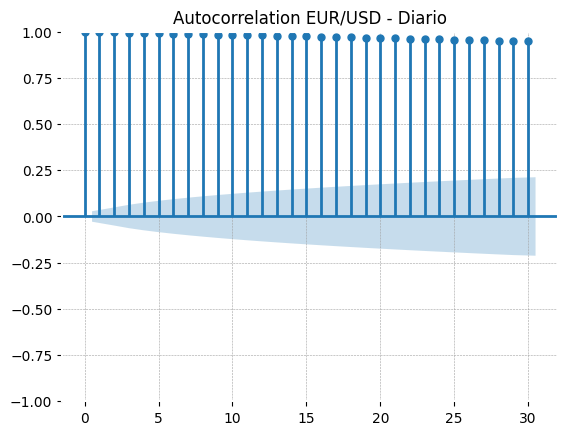

In [33]:
from statsmodels.graphics.tsaplots import plot_acf

# Diario
bc_daily = df_5m['BC'].resample('D').median().dropna()
plt.figure(figsize=(5.5, 5.5))
plot_acf(bc_daily, lags=30)
plt.title('Autocorrelation EUR/USD - Diario')
plt.show()

# 5 minutos
plt.figure(figsize=(5.5, 5.5))
plot_acf(df_5m['BC'], lags=30)
plt.title('Autocorrelation EUR/USD - 5 minutos')
plt.show()

Autocorrelación Parcial

<Figure size 550x550 with 0 Axes>

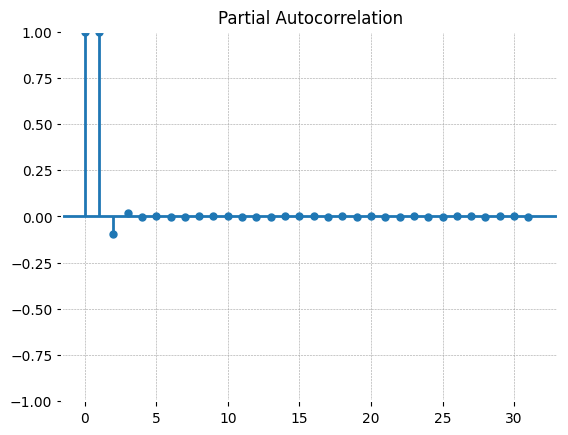

In [94]:
plt.figure(figsize=(5.5, 5.5));
plot_pacf(df_5m['BC'], lags=31);

Análisis de datos de series temporales

Remuestreo de datos de series temporales

La técnica de remuestreo se ha aplicado en las secciones anteriores para realizar análisis de tendencia, ciclo y estacionalidad, además de usarlas para comparar el comportamiento de autocorrelación en un nivel de agregación mayor.

In [95]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Se realiza el remuestreo para comparar el precio de cierre cada 5 minutos y diario.

Text(0, 0.5, 'Precio Cierre Bid')

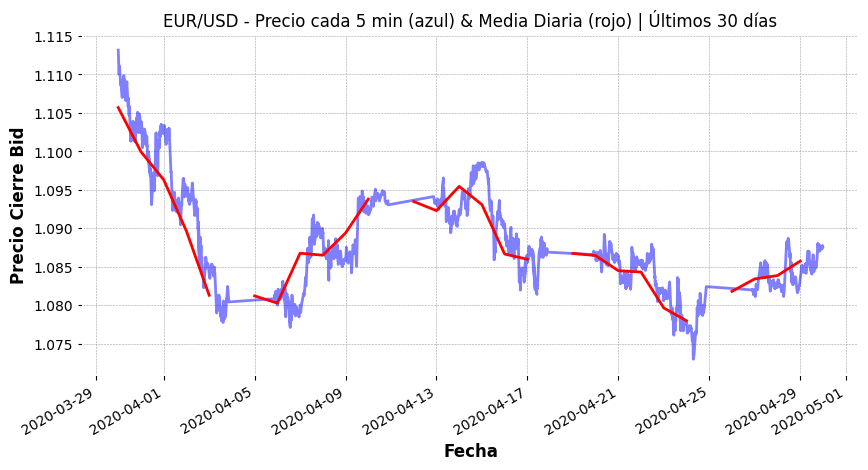

In [96]:
bc_5min_window = df_5m['BC']['2020-03-30':'2020-04-29']
bc_daily_window = df_5m['BC'].resample('D').mean()['2020-03-30':'2020-04-29']

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,1,1)
bc_5min_window.plot(ax=ax, color='b', alpha=0.5)
bc_daily_window.plot(ax=ax, color='r', linewidth=2)
ax.set_title('EUR/USD - Precio cada 5 min (azul) & Media Diaria (rojo) | Últimos 30 días')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio Cierre Bid')

Se compara el precio de cierre agrupado a nivel mensual y se compara con su desviación estándar

                  BC Month_Year
Date                           
2005-01-02  1.355530    01-2005
2005-01-03  1.348946    01-2005
2005-01-04  1.337940    01-2005
2005-01-05  1.326501    01-2005
2005-01-06  1.320725    01-2005
   Month_Year      mean    median       std  Year Month
0     01-2005  1.312890  1.307208  0.014921  2005    01
16    02-2005  1.301424  1.302746  0.015242  2005    02
32    03-2005  1.319119  1.321176  0.018217  2005    03
48    04-2005  1.293964  1.292261  0.007341  2005    04
64    05-2005  1.268895  1.263558  0.015837  2005    05


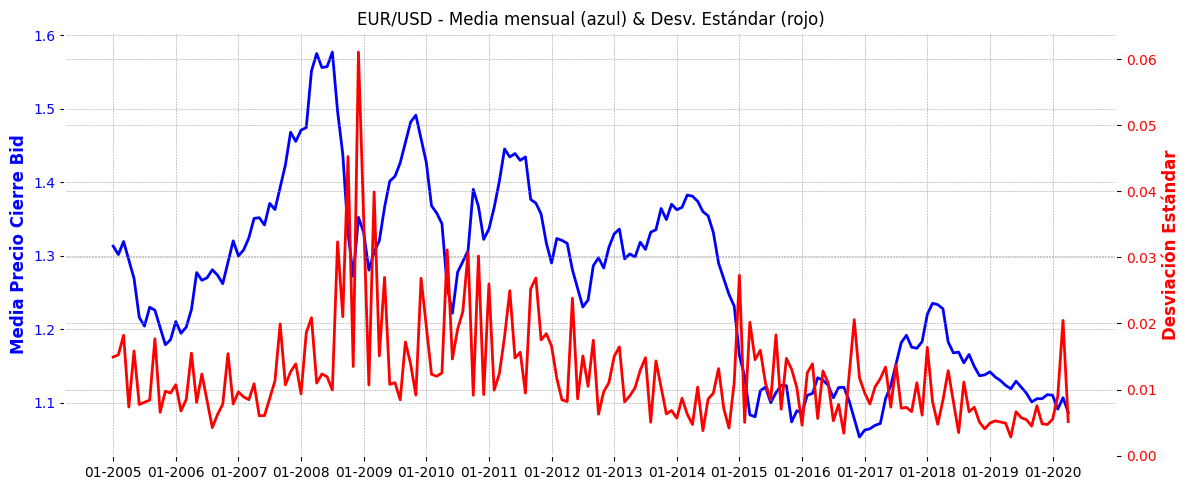

In [97]:
# Paso 1 - De 5 minutos a diario
df_daily = df_5m['BC'].resample('D').mean().reset_index()
df_daily.columns = ['Date', 'BC']
df_daily.set_index('Date', inplace=True)

# Paso 2 - Agregar columna Month_Year
df_daily['Month_Year'] = df_daily.index.map(lambda d: d.strftime('%m-%Y'))
print(df_daily.head())

# Paso 3 - Estadísticas mensuales
monthly_stats = df_daily.groupby(by='Month_Year')['BC'].aggregate([np.mean, np.median, np.std])
monthly_stats.reset_index(inplace=True)

# Paso 4 - Ordenar por año y mes
monthly_stats['Year'] = monthly_stats['Month_Year'].map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%Y'))
monthly_stats['Month'] = monthly_stats['Month_Year'].map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%m'))
monthly_stats.sort_values(by=['Year', 'Month'], inplace=True)

print(monthly_stats.head())

# Paso 5 - Grafica
monthly_stats.index = monthly_stats['Month_Year']


fig, ax1 = plt.subplots(figsize=(12, 5))

# Media en eje izquierdo
ax1.plot(monthly_stats['mean'].values, color='b', label='Media')
ax1.set_ylabel('Media Precio Cierre Bid', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Std en eje derecho
ax2 = ax1.twinx()
ax2.plot(monthly_stats['std'].values, color='r', label='Std')
ax2.set_ylabel('Desviación Estándar', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('EUR/USD - Media mensual (azul) & Desv. Estándar (rojo)')
plt.xticks(range(0, len(monthly_stats), 12), monthly_stats['Month_Year'].values[::12], rotation=45)
plt.tight_layout()
plt.show()

Estadísticos móviles

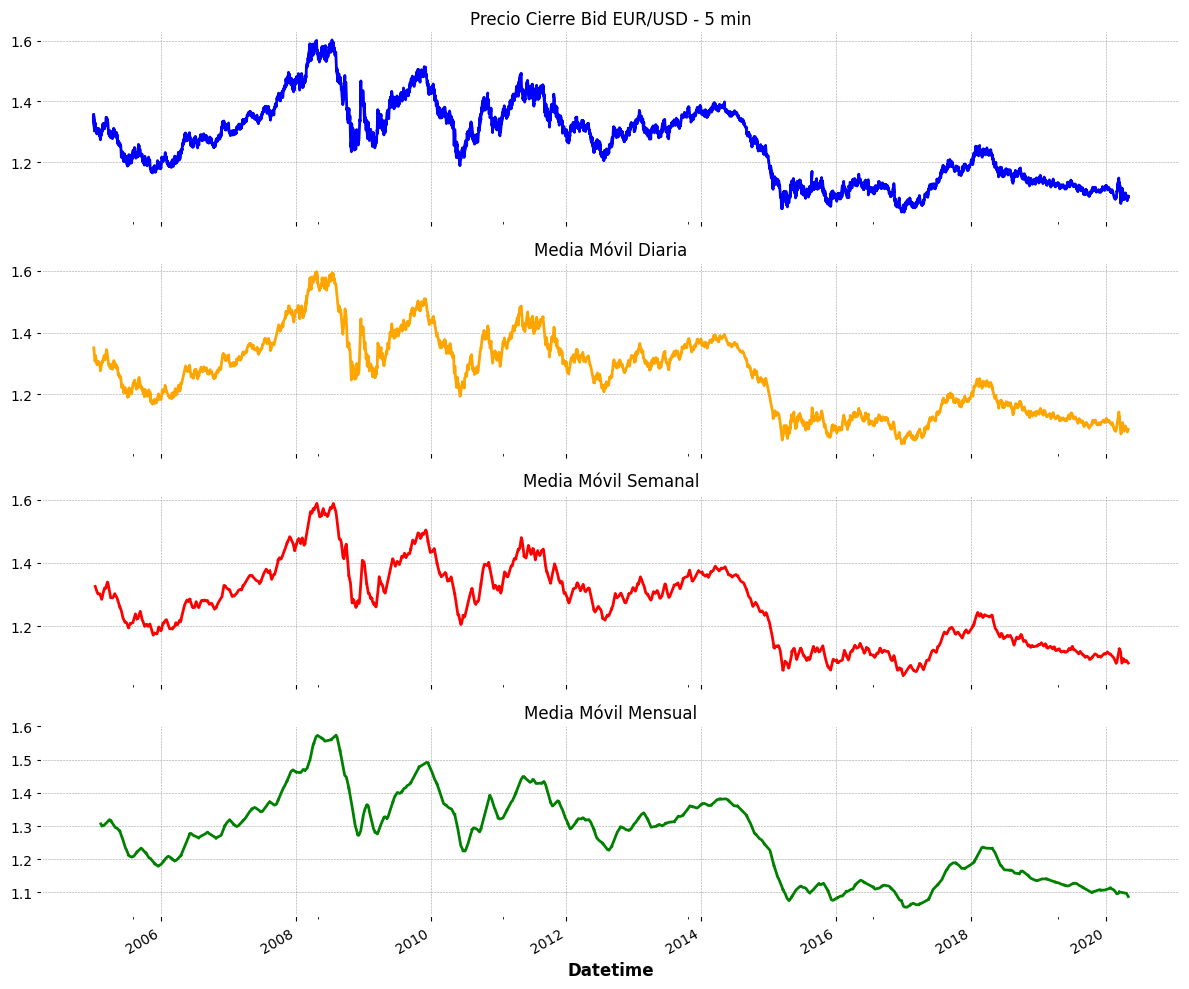

In [99]:
# Medias móviles
daily_moving_average = df_5m['BC'].rolling(24*12).mean()      # 1 día en periodos de 5 min
weekly_moving_average = df_5m['BC'].rolling(7*24*12).mean()   # 7 días en periodos de 5 min
monthly_moving_average = df_5m['BC'].rolling(30*24*12).mean() # 30 días en periodos de 5 min

fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(12, 10)

df_5m['BC'].plot(ax=axarr[0], color='b')
axarr[0].set_title('Precio Cierre Bid EUR/USD - 5 min')

daily_moving_average.plot(ax=axarr[1], color='orange')
axarr[1].set_title('Media Móvil Diaria')

weekly_moving_average.plot(ax=axarr[2], color='r')
axarr[2].set_title('Media Móvil Semanal')

monthly_moving_average.plot(ax=axarr[3], color='g')
axarr[3].set_title('Media Móvil Mensual')

plt.tight_layout()
plt.show()

Procesos estacionarios


Transformación de datos y ajustes

Ajustes estacionales y de tendencia

Diferenciación

In [105]:
from random import seed
from pandas import Series
import random 
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa import stattools
from pandas.plotting import autocorrelation_plot

In [107]:
first_order_diff = df_5m['BC'].diff(1)
first_order_diff

Datetime
2005-01-02 18:25:00         NaN
2005-01-02 18:35:00    0.000000
2005-01-02 18:50:00    0.000600
2005-01-02 18:55:00    0.000150
2005-01-02 19:00:00    0.000150
                         ...   
2020-04-29 23:35:00    0.000145
2020-04-29 23:40:00    0.000030
2020-04-29 23:45:00    0.000010
2020-04-29 23:50:00   -0.000030
2020-04-29 23:55:00   -0.000120
Name: BC, Length: 1153890, dtype: float64

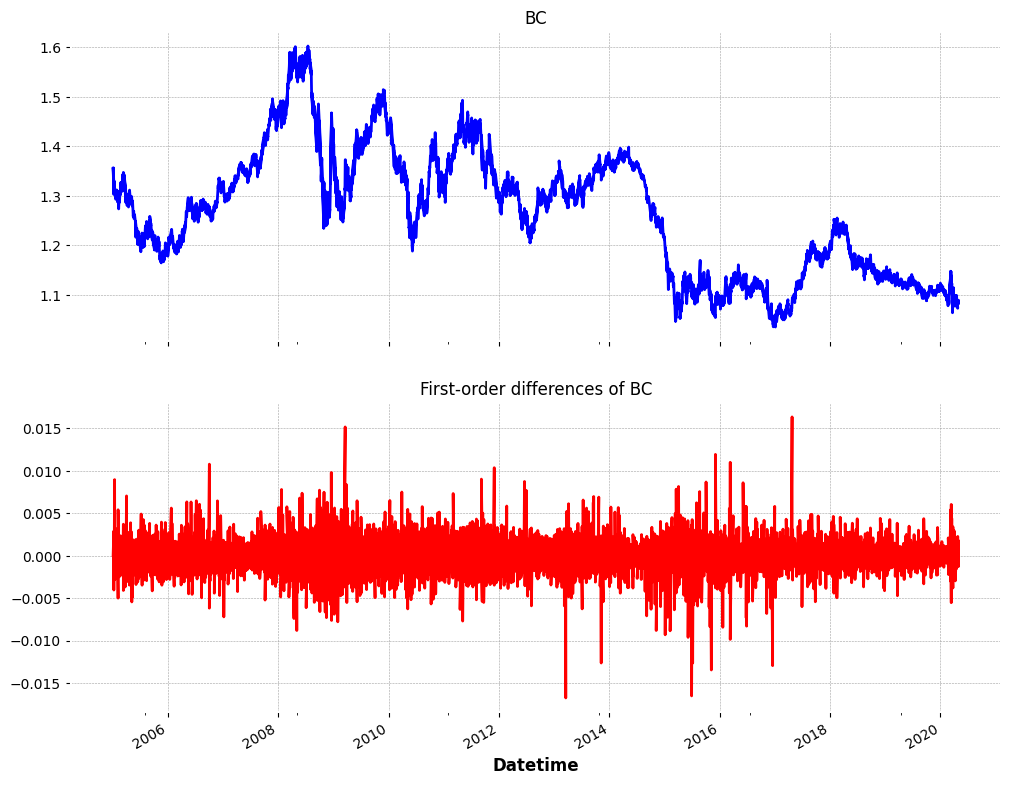

In [110]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(12, 10)
df_5m['BC'].plot(ax=ax[0], color='b');
ax[0].set_title('BC');
first_order_diff.plot(ax=ax[1], color='r');
ax[1].set_title('First-order differences of BC');

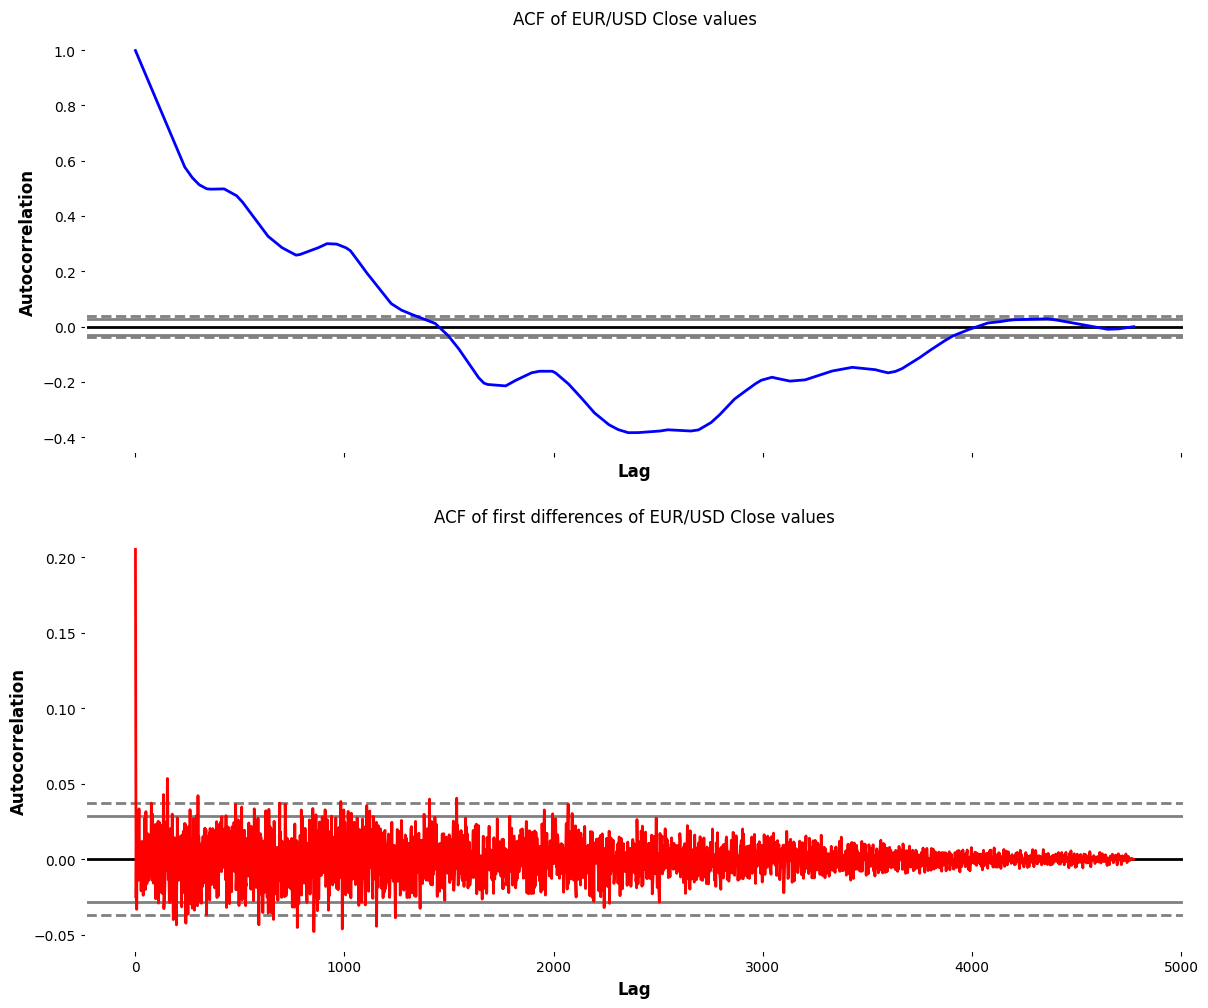

In [134]:
from pandas.plotting import autocorrelation_plot

bc_daily = df_5m['BC'].resample('D').median().dropna()
first_order_diff = bc_daily.diff().dropna()

fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(12, 10)
autocorrelation_plot(bc_daily, color='b', ax=ax[0])
ax[0].set_title('ACF of EUR/USD Close values')
autocorrelation_plot(first_order_diff.iloc[1:], color='r', ax=ax[1])
ax[1].set_title('ACF of first differences of EUR/USD Close values')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [ ]:
acf_BC, confint_BC, qstat_BC, pvalues_BC = stattools.acf(df_5m['BC'],
                                                                 nlags=20,
                                                                 qstat=True,
                                                                 alpha=0.05)



In [127]:
alpha = 0.05
for l, p_val in enumerate(pvalues_BC):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 0.0
Null hypothesis is rejected at lag = 1 for p-val = 0.0
Null hypothesis is rejected at lag = 2 for p-val = 0.0
Null hypothesis is rejected at lag = 3 for p-val = 0.0
Null hypothesis is rejected at lag = 4 for p-val = 0.0
Null hypothesis is rejected at lag = 5 for p-val = 0.0
Null hypothesis is rejected at lag = 6 for p-val = 0.0
Null hypothesis is rejected at lag = 7 for p-val = 0.0
Null hypothesis is rejected at lag = 8 for p-val = 0.0
Null hypothesis is rejected at lag = 9 for p-val = 0.0
Null hypothesis is rejected at lag = 10 for p-val = 0.0
Null hypothesis is rejected at lag = 11 for p-val = 0.0
Null hypothesis is rejected at lag = 12 for p-val = 0.0
Null hypothesis is rejected at lag = 13 for p-val = 0.0
Null hypothesis is rejected at lag = 14 for p-val = 0.0
Null hypothesis is rejected at lag = 15 for p-val = 0.0
Null hypothesis is rejected at lag = 16 for p-val = 0.0
Null hypothesis is rejected at lag = 17 for p-val = 0.0
Nu

In [129]:
acf_first_diff, confint_first_diff,\
qstat_first_diff, pvalues_first_diff = stattools.acf(first_order_diff.iloc[1:],
                                                     nlags=20,
                                                     qstat=True,
                                                     alpha=0.05)

In [130]:
alpha = 0.05
for l, p_val in enumerate(pvalues_first_diff):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 1.2272822948081776e-45
Null hypothesis is rejected at lag = 1 for p-val = 1.568828974253562e-44
Null hypothesis is rejected at lag = 2 for p-val = 1.7686297922617214e-43
Null hypothesis is rejected at lag = 3 for p-val = 3.3068872748673155e-43
Null hypothesis is rejected at lag = 4 for p-val = 1.6412028195765364e-42
Null hypothesis is rejected at lag = 5 for p-val = 4.3175352336063026e-42
Null hypothesis is rejected at lag = 6 for p-val = 2.033537024347313e-42
Null hypothesis is rejected at lag = 7 for p-val = 9.778278312981476e-42
Null hypothesis is rejected at lag = 8 for p-val = 1.407041510332198e-41
Null hypothesis is rejected at lag = 9 for p-val = 5.429461874674374e-41
Null hypothesis is rejected at lag = 10 for p-val = 2.373243304169236e-40
Null hypothesis is rejected at lag = 11 for p-val = 1.033925571044662e-39
Null hypothesis is rejected at lag = 12 for p-val = 4.509629219379712e-39
Null hypothesis is rejected at lag = 13 for

Podemos ver su comportamiento estacional y aplicar las pruebas de ACF y ACF parcial

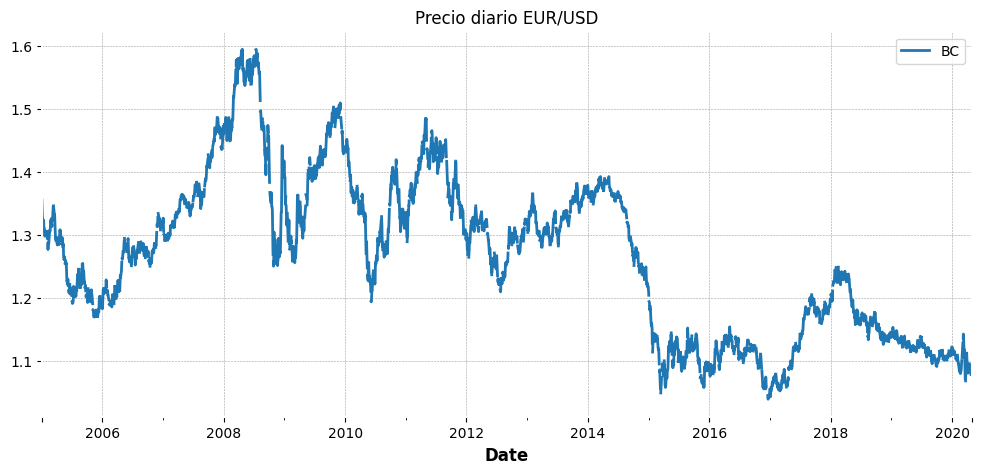

In [136]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Precio diario EUR/USD')
df_daily.plot(ax=ax)
plt.show()

Shape of monthly mean EUR/USD dataset: (184,)
Datetime
2005-01-31    1.312525
2005-02-28    1.301520
2005-03-31    1.318475
2005-04-30    1.293962
2005-05-31    1.269107
Freq: ME, Name: BC, dtype: float64


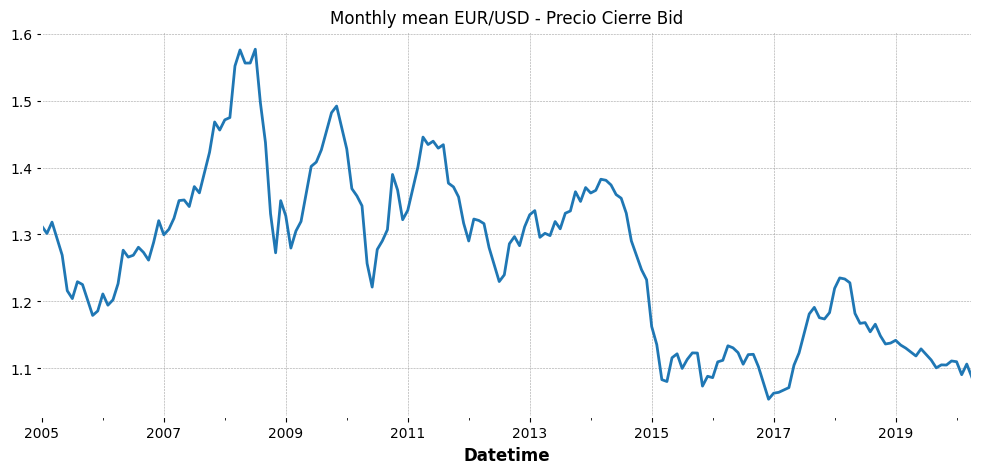

In [137]:
monthly_resample = df_5m['BC'].resample('M')
monthly_mean_bc = monthly_resample.mean()

print('Shape of monthly mean EUR/USD dataset:', monthly_mean_bc.shape)
print(monthly_mean_bc.head())

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Monthly mean EUR/USD - Precio Cierre Bid')
monthly_mean_bc.plot(ax=ax)
plt.show()

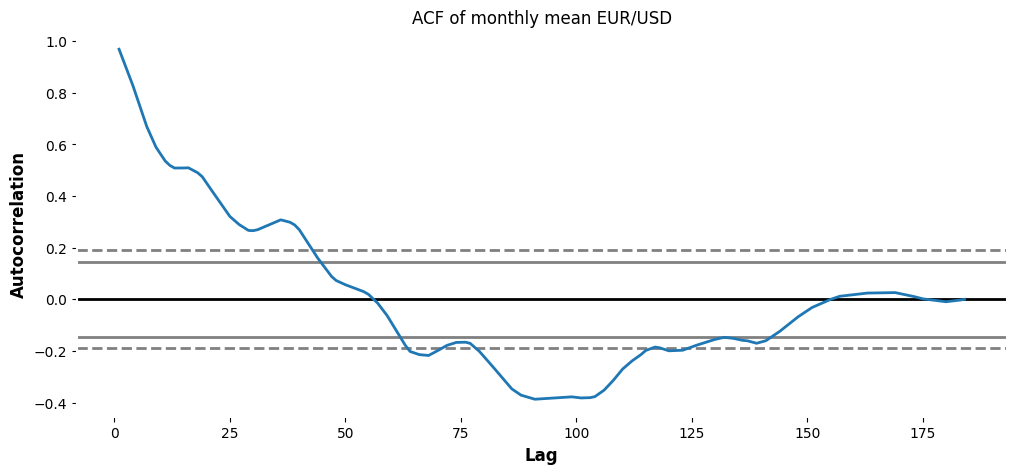

In [139]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of monthly mean EUR/USD')
autocorrelation_plot(monthly_mean_bc, ax=ax)
plt.show()

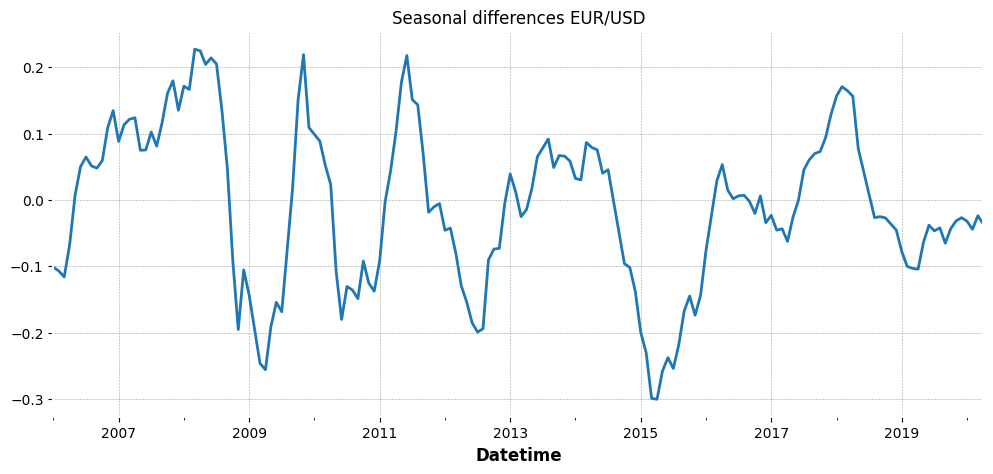

In [142]:
seasonal_diff = monthly_mean_bc.diff(12)
seasonal_diff = seasonal_diff[12:]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Seasonal differences EUR/USD')
seasonal_diff.plot(ax=ax)
plt.show()

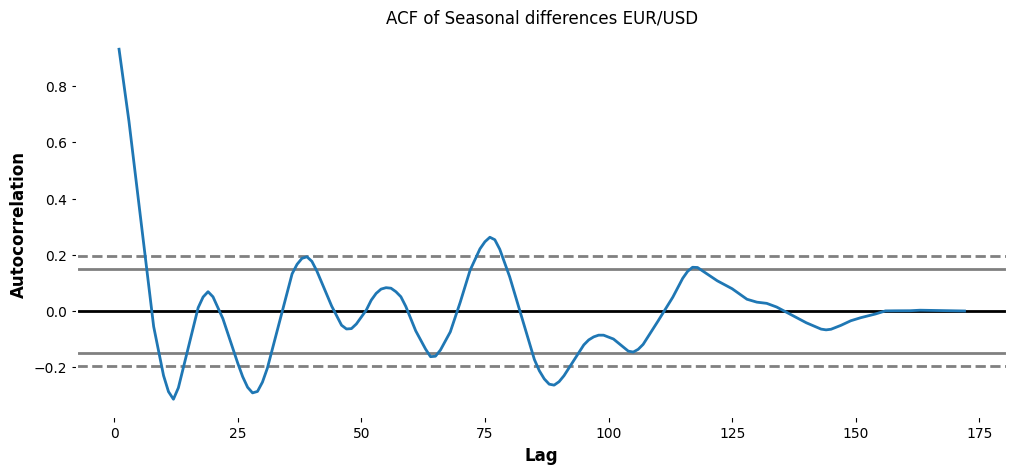

In [144]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of Seasonal differences EUR/USD')
autocorrelation_plot(seasonal_diff, ax=ax)
plt.show()

In [145]:
from statsmodels.tsa import stattools

# Ljung-Box sobre media mensual
_, _, _, pval_monthly_mean = stattools.acf(monthly_mean_bc, nlags=10, qstat=True, alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean <= 0.05))

# Ljung-Box sobre diferencias estacionales
_, _, _, pval_seasonal_diff = stattools.acf(seasonal_diff, nlags=10, qstat=True, alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_seasonal_diff <= 0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)
Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)


Prueba de Dickey-Fuller

In [146]:
adf_result = stattools.adfuller(df_5m['BC'], autolag='AIC')
print('p-val of the ADF test in EUR/USD monthly mean:', adf_result[1])

p-val of the ADF test in EUR/USD monthly mean: 0.4329592567477676


Descomposición de series temporales

Medias móviles y efectos de suavización


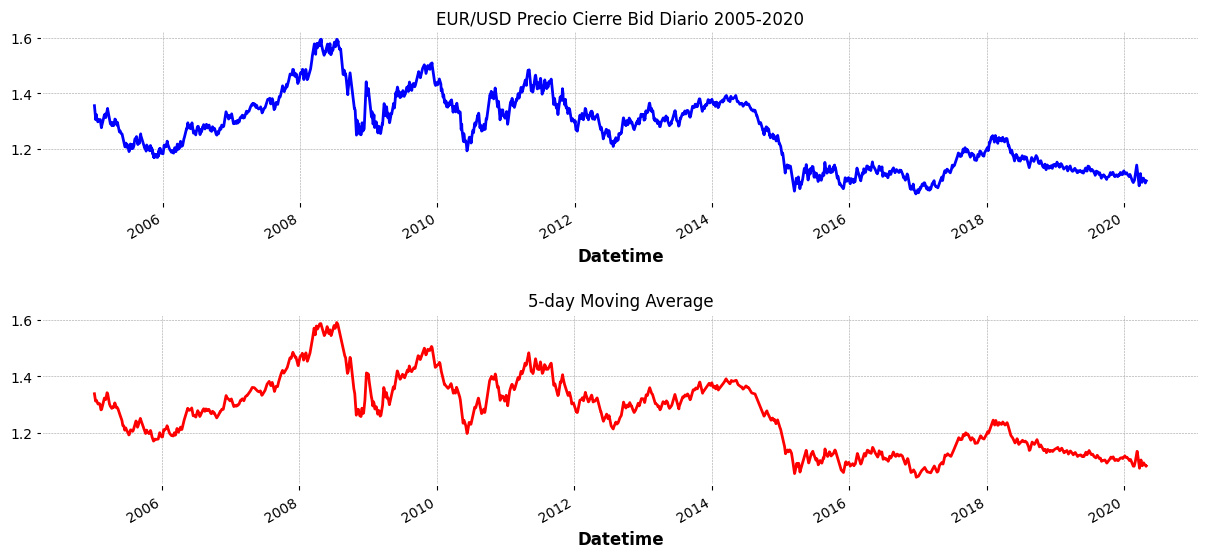

In [149]:
# Resamplear a diario
bc_daily_ma = df_5m['BC'].resample('D').mean().dropna()

# Media móvil de 5 días
bc_daily_ma_5 = bc_daily_ma.rolling(5).mean()

# Grafica
fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(2,1,1)
bc_daily_ma.plot(ax=ax, color='b')
ax.set_title('EUR/USD Precio Cierre Bid Diario 2005-2020')

ax = fig.add_subplot(2,1,2)
bc_daily_ma_5.plot(ax=ax, color='r')
ax.set_title('5-day Moving Average')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

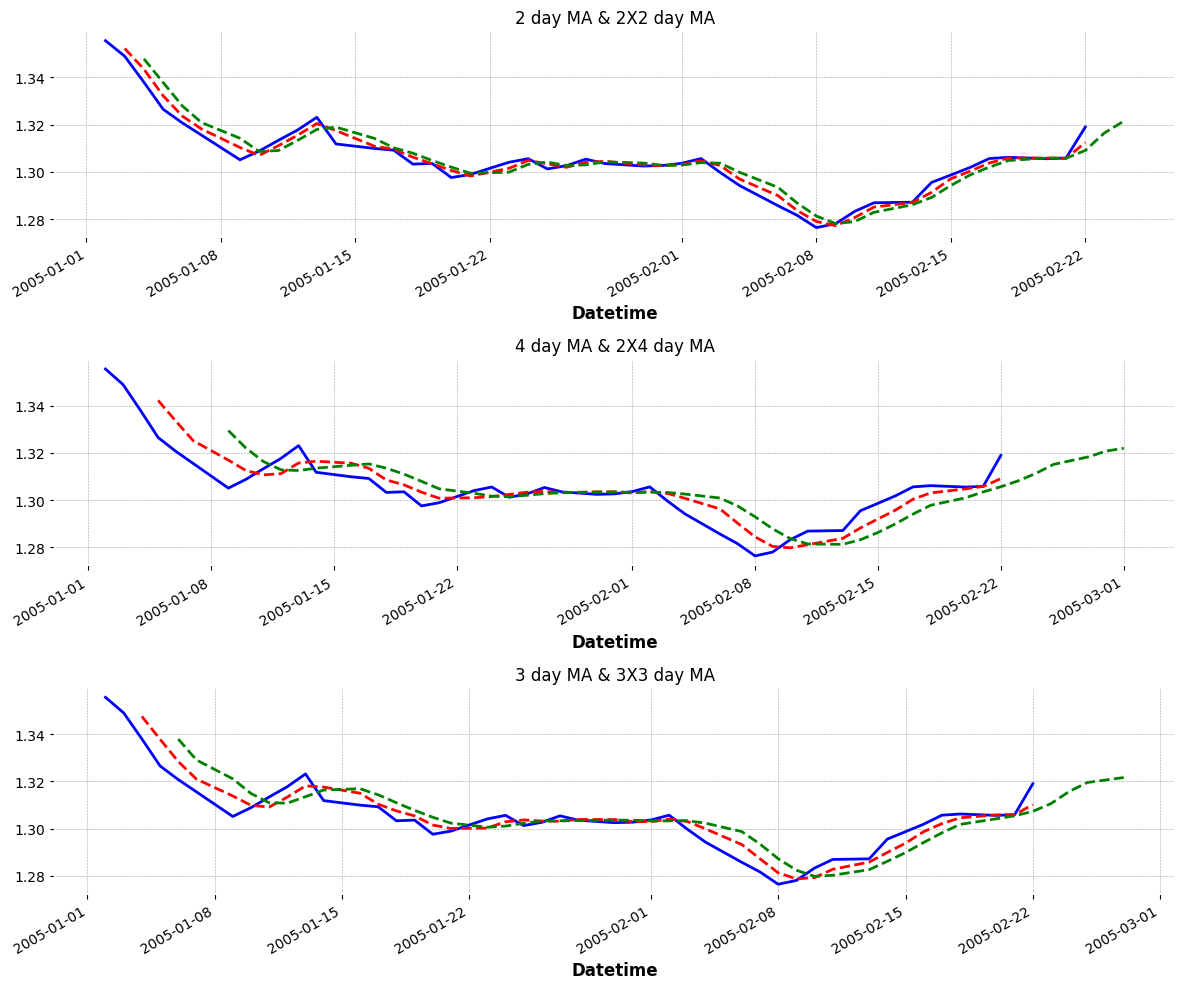

In [152]:
# Medias móviles
MA2 = bc_daily_ma.rolling(window=2).mean()
TwoXMA2 = MA2.rolling(window=2).mean()

MA4 = bc_daily_ma.rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=4).mean()

MA3 = bc_daily_ma.rolling(window=3).mean()
ThreeXMA3 = MA3.rolling(window=3).mean()

# Eliminar NaN
TwoXMA2 = TwoXMA2.dropna()
TwoXMA4 = TwoXMA4.dropna()
ThreeXMA3 = ThreeXMA3.dropna()

# Grafica
f, axarr = plt.subplots(3, sharex=False)
f.set_size_inches(12, 10)

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[0])
MA2.iloc[:45].plot(color='r', linestyle='--', ax=axarr[0])
TwoXMA2.iloc[:45].plot(color='g', linestyle='--', ax=axarr[0])
axarr[0].set_title('2 day MA & 2X2 day MA')

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[1])
MA4.iloc[:45].plot(color='r', linestyle='--', ax=axarr[1])
TwoXMA4.iloc[:45].plot(color='g', linestyle='--', ax=axarr[1])
axarr[1].set_title('4 day MA & 2X4 day MA')

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[2])
MA3.iloc[:45].plot(color='r', linestyle='--', ax=axarr[2])
ThreeXMA3.iloc[:45].plot(color='g', linestyle='--', ax=axarr[2])
axarr[2].set_title('3 day MA & 3X3 day MA')

plt.tight_layout()
plt.show()

## Ajuste estacional mediante media móvil

El EUR/USD muestra una serie temporal no estacionaria con memoria persistente, confirmada por la prueba ADF (p-val = 0.43) y la autocorrelación significativa en todos los rezagos analizados. La serie presenta una tendencia no lineal clara: una fase alcista entre 2005 y 2008 que llevó el par hasta niveles de 1.60, seguida de una caída abrupta durante la crisis financiera de 2008-2009, una recuperación parcial hasta 2011, y una tendencia bajista sostenida desde 2014 que estabilizó el precio alrededor de 1.10. La descomposición mensual revela que la variabilidad del precio es baja y relativamente constante a lo largo del tiempo, con una desviación estándar mensual que no supera 0.05, lo que indica que aunque el nivel del precio cambia estructuralmente, la volatilidad intrínseca de la serie es estable.

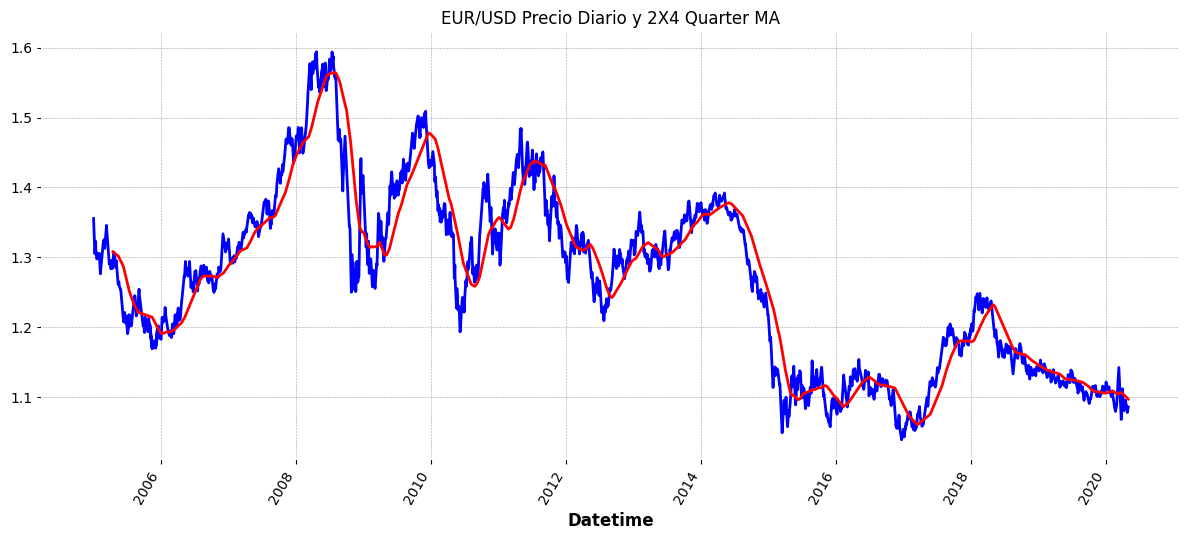

In [162]:
MA4 = bc_daily_ma.rolling(window=90).mean()
TwoXMA4 = MA4.rolling(window=2).mean()
TwoXMA4 = TwoXMA4.loc[~pd.isnull(TwoXMA4)]

fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(1,1,1)
bc_daily_ma.plot(ax=ax, color='b', linestyle='-')
TwoXMA4.plot(ax=ax, color='r', linestyle='-')
plt.xticks(rotation=60)
ax.set_title('EUR/USD Precio Diario y 2X4 Quarter MA')
plt.tight_layout()
plt.show()